In [5]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, GridSearchCV, KFold

In [6]:
# Load dataset
df = pd.DataFrame(pd.read_csv('C:\\Users\\W.G uresha ishwari\\OneDrive\\Desktop\\ML\\Supermarket_Predictor\\supermarket_data.csv'))
df.head()

,Age,Gender,Monthly Income (LKR),Family Size,Residential Area,Budget (LKR),Frequency,Transport,Supermarket
0,18-25,Female,"Below 30,000",1-2 people,Rural,"Below 10,000",Bi-weekly,Walking,Spar Super Markert
1,18-25,Female,"Below 30,000",1-2 people,Urban,"Below 10,000",Weekly,Private Vehicle,Keells
2,18-25,Female,"30,000 - 50,000",3-4 people,Urban,"10,000 - 20,000",Monthly,Walking,Sathosa
3,18-25,Male,"50,001 - 80,000",1-2 people,Suburban,"10,000 - 20,000",Weekly,Private Vehicle,Keells
4,18-25,Female,"50,001 - 80,000",3-4 people,Suburban,"Above 40,000",Monthly,Public Transport,Cargills FoodCity


Dataset Overview

In [ ]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
df.info()

Dataset Shape: (520, 9)

Column Names:
Index(['Age', 'Gender  ', 'Monthly Income (LKR)  ', 'Family Size  ',
       'Residential Area  ', ' Budget (LKR)  ', 'Frequency', 'Transport',
       'Supermarket'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Age                     520 non-null    object
 1   Gender                  520 non-null    object
 2   Monthly Income (LKR)    520 non-null    object
 3   Family Size             520 non-null    object
 4   Residential Area        520 non-null    object
 5    Budget (LKR)           520 non-null    object
 6   Frequency               520 non-null    object
 7   Transport               520 non-null    object
 8   Supermarket             520 non-null    object
dtypes: object(9)
memory usage: 36.7+ KB


Clean Column Names

In [ ]:
# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Replace spaces with underscores
df.columns = df.columns.str.replace(" ", "_")

print(df.columns)

Index(['Age', 'Gender', 'Monthly_Income_(LKR)', 'Family_Size',
       'Residential_Area', 'Budget_(LKR)', 'Frequency', 'Transport',
       'Supermarket'],
      dtype='object')


Check Missing Values

In [ ]:
print(df.isnull().sum())

Age                     0
Gender                  0
Monthly_Income_(LKR)    0
Family_Size             0
Residential_Area        0
Budget_(LKR)            0
Frequency               0
Transport               0
Supermarket             0
dtype: int64


In [7]:
df.describe(include="all")

,Age,Gender,Monthly Income (LKR),Family Size,Residential Area,Budget (LKR),Frequency,Transport,Supermarket
count,520,520,520,520,520,520,520,520,520
unique,6,3,5,4,3,4,4,5,10
top,36-45,Female,"30,000 - 50,000",3-4 people,Suburban,"10,000 - 20,000",Bi-weekly,Public Transport,Cargills FoodCity
freq,136,293,186,288,265,276,240,195,133


In [8]:
for column in df.select_dtypes(include="object").columns:
    if df[column].isnull().sum() > 0:
        df[column] = df[column].fillna(df[column].mode()[0])

Check Duplicate Rows

In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 11


In [ ]:
#Remove Duplicates
df = df.drop_duplicates()
print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (509, 9)


In [ ]:
# Remove extra spaces
df["Supermarket"] = df["Supermarket"].str.strip()

# Standardize supermarket names
df["Supermarket"] = df["Supermarket"].replace({
    "Spar Super Markert": "SPAR",
    "Cargills FoodCity": "Cargills Food City",
    "Co-operative stores": "Co-operative Store"
})

# Check supermarket counts
print(df["Supermarket"].value_counts())

Supermarket
Cargills Food City               128
Keells                            98
SPAR                              86
Arpico                            76
Sathosa                           68
Sampath                           30
Glomark                           19
Co-operative Store                 2
Jayathissa Stores, Meerigama.      1
Ashoka FoodCity                    1
Name: count, dtype: int64


In [10]:
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    df[column] = df[column].str.strip()

In [ ]:
# 1. Clean columns
df.columns = df.columns.str.strip()


# 2. Define categorical columns
categorical_columns = df.select_dtypes(include="object").columns


for column in categorical_columns:
    print(column)
    print(df[column].unique())
    print()

Age
['18-25' '26-35' '36-45' 'above 55' '45-55' 'Below 18']

Gender
['Female' 'Male' 'Prefer not to say']

Monthly Income (LKR)
['Below 30,000' '30,000 - 50,000' '50,001 - 80,000' 'Above 120,000'
 '80,001 - 120,000']

Family Size
['1-2 people' '3-4 people' '5-6 people' 'More than 6 people']

Residential Area
['Rural' 'Urban' 'Suburban']

Budget (LKR)
['Below 10,000' '10,000 - 20,000' 'Above 40,000' '20,001 - 40,000']

Frequency
['Bi-weekly' 'Weekly' 'Monthly' 'Less than once a month']

Transport
['Walking' 'Private Vehicle' 'Public Transport' 'Taxi / Ride-hailing'
 'Other']

Supermarket
['Spar Super Markert' 'Keells' 'Sathosa' 'Cargills FoodCity' 'Arpico'
 'Glomark' 'Co-operative stores' 'Sampath' 'Jayathissa Stores, Meerigama.'
 'Ashoka FoodCity']



In [24]:
df.columns = df.columns.str.strip()

In [15]:
df.head()


,Age,Gender,Monthly Income (LKR),Family Size,Residential Area,Budget (LKR),Frequency,Transport,Supermarket
0,18-25,Female,"Below 30,000",1-2 people,Rural,"Below 10,000",Bi-weekly,Walking,Spar Super Markert
1,18-25,Female,"Below 30,000",1-2 people,Urban,"Below 10,000",Weekly,Private Vehicle,Keells
2,18-25,Female,"30,000 - 50,000",3-4 people,Urban,"10,000 - 20,000",Monthly,Walking,Sathosa
3,18-25,Male,"50,001 - 80,000",1-2 people,Suburban,"10,000 - 20,000",Weekly,Private Vehicle,Keells
4,18-25,Female,"50,001 - 80,000",3-4 people,Suburban,"Above 40,000",Monthly,Public Transport,Cargills FoodCity


In [18]:
print(df.columns.tolist())


['Age', 'Gender  ', 'Monthly Income (LKR)  ', 'Family Size  ', 'Residential Area  ', ' Budget (LKR)  ', 'Frequency', 'Transport', 'Supermarket']


In [22]:
# Remove extra spaces from column names

df.columns = df.columns.str.strip()
print(df.columns.tolist())

['Age', 'Gender', 'Monthly Income (LKR)', 'Family Size', 'Residential Area', 'Budget (LKR)', 'Frequency', 'Transport', 'Supermarket']


In [20]:
x = df[
[
    "Age",
    "Gender",
    "Monthly Income (LKR)",
    "Family Size",
    "Residential Area",
    "Budget (LKR)",
    "Frequency",
    "Transport"
]
]


y = df["Supermarket"]

In [ ]:
df.head()

,Age,Gender,Monthly_Income_(LKR),Family_Size,Residential_Area,Budget_(LKR),Frequency,Transport,Supermarket
0,18-25,Female,"Below 30,000",1-2 people,Rural,"Below 10,000",Bi-weekly,Walking,SPAR
1,18-25,Female,"Below 30,000",1-2 people,Urban,"Below 10,000",Weekly,Private Vehicle,Keells
2,18-25,Female,"30,000 - 50,000",3-4 people,Urban,"10,000 - 20,000",Monthly,Walking,Sathosa
3,18-25,Male,"50,001 - 80,000",1-2 people,Suburban,"10,000 - 20,000",Weekly,Private Vehicle,Keells
4,18-25,Female,"50,001 - 80,000",3-4 people,Suburban,"Above 40,000",Monthly,Public Transport,Cargills Food City


In [21]:
x_encoded = pd.get_dummies(x, drop_first=True)
print(x_encoded.head())

   Age_26-35  Age_36-45  Age_45-55  Age_Below 18  Age_above 55  Gender_Male  \
0      False      False      False         False         False        False   
1      False      False      False         False         False        False   
2      False      False      False         False         False        False   
3      False      False      False         False         False         True   
4      False      False      False         False         False        False   

   Gender_Prefer not to say  Monthly Income (LKR)_50,001 - 80,000  \
0                     False                                 False   
1                     False                                 False   
2                     False                                 False   
3                     False                                  True   
4                     False                                  True   

   Monthly Income (LKR)_80,001 - 120,000  Monthly Income (LKR)_Above 120,000  \
0                             

In [ ]:
x = df.iloc[:, :-1]
y = df.iloc[:, -1]

print(x.head())
print(y.head())

     Age  Gender Monthly_Income_(LKR) Family_Size Residential_Area  \
0  18-25  Female         Below 30,000  1-2 people            Rural   
1  18-25  Female         Below 30,000  1-2 people            Urban   
2  18-25  Female      30,000 - 50,000  3-4 people            Urban   
3  18-25    Male      50,001 - 80,000  1-2 people         Suburban   
4  18-25  Female      50,001 - 80,000  3-4 people         Suburban   

      Budget_(LKR)  Frequency         Transport  
0     Below 10,000  Bi-weekly           Walking  
1     Below 10,000     Weekly   Private Vehicle  
2  10,000 - 20,000    Monthly           Walking  
3  10,000 - 20,000     Weekly   Private Vehicle  
4     Above 40,000    Monthly  Public Transport  
0                  SPAR
1                Keells
2               Sathosa
3                Keells
4    Cargills Food City
Name: Supermarket, dtype: object


In [ ]:
x = pd.get_dummies(x, dtype=int)
x.head()

,Age_18-25,Age_26-35,Age_36-45,Age_45-55,Age_Below 18,Age_above 55,Gender_Female,Gender_Male,Gender_Prefer not to say,"Monthly_Income_(LKR)_30,000 - 50,000",...,"Budget_(LKR)_Below 10,000",Frequency_Bi-weekly,Frequency_Less than once a month,Frequency_Monthly,Frequency_Weekly,Transport_Other,Transport_Private Vehicle,Transport_Public Transport,Transport_Taxi / Ride-hailing,Transport_Walking
0,1,0,0,0,0,0,1,0,0,0,...,1,1,0,0,0,0,0,0,0,1
1,1,0,0,0,0,0,1,0,0,0,...,1,0,0,0,1,0,1,0,0,0
2,1,0,0,0,0,0,1,0,0,1,...,0,0,0,1,0,0,0,0,0,1
3,1,0,0,0,0,0,0,1,0,0,...,0,0,0,0,1,0,1,0,0,0
4,1,0,0,0,0,0,1,0,0,0,...,0,0,0,1,0,0,0,1,0,0


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y,test_size=0.2,random_state=42)

In [ ]:
len(x_test)

102

In [ ]:
len(x_train)

407

Decision Tree Model

In [ ]:
clt = DecisionTreeClassifier()
clt.fit(x_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [ ]:
y_pred=clt.predict(x_test)
y_pred

array(['Keells', 'SPAR', 'Sathosa', 'Arpico', 'SPAR',
       'Cargills Food City', 'Arpico', 'SPAR', 'Keells', 'Glomark',
       'SPAR', 'Arpico', 'Sathosa', 'Cargills Food City',
       'Cargills Food City', 'SPAR', 'Keells', 'Cargills Food City',
       'Keells', 'SPAR', 'SPAR', 'Sathosa', 'Arpico',
       'Cargills Food City', 'Arpico', 'Glomark', 'Cargills Food City',
       'Cargills Food City', 'Cargills Food City', 'Keells',
       'Cargills Food City', 'Cargills Food City', 'SPAR', 'Glomark',
       'Keells', 'Glomark', 'Keells', 'Arpico', 'Sathosa', 'Keells',
       'Sampath', 'Cargills Food City', 'Arpico', 'Cargills Food City',
       'Cargills Food City', 'Keells', 'Sampath', 'Cargills Food City',
       'Cargills Food City', 'Co-operative Store', 'SPAR', 'Glomark',
       'Cargills Food City', 'Keells', 'Keells', 'SPAR',
       'Cargills Food City', 'Cargills Food City', 'Arpico', 'Keells',
       'Keells', 'Sathosa', 'Cargills Food City', 'Arpico', 'Arpico',
       'Cargi

In [ ]:
confusion_matrix(y_test,y_pred)

array([[ 3,  4,  1,  1,  0,  2,  3,  0,  1],
       [ 2, 10,  0,  1,  0,  5,  2,  1,  4],
       [ 0,  1,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  1,  1],
       [ 0,  0,  0,  0,  0,  0,  1,  0,  0],
       [ 4,  9,  0,  1,  0,  4,  4,  3,  2],
       [ 2,  1,  0,  4,  0,  3,  3,  0,  1],
       [ 0,  1,  0,  0,  0,  1,  1,  0,  0],
       [ 4,  4,  0,  0,  0,  2,  4,  0,  0]])

In [ ]:
y.value_counts()

Supermarket
Cargills Food City               128
Keells                            98
SPAR                              86
Arpico                            76
Sathosa                           68
Sampath                           30
Glomark                           19
Co-operative Store                 2
Jayathissa Stores, Meerigama.      1
Ashoka FoodCity                    1
Name: count, dtype: int64

In [ ]:
print(classification_report(y_test,y_pred))

                               precision    recall  f1-score   support

                       Arpico       0.20      0.20      0.20        15
           Cargills Food City       0.33      0.40      0.36        25
           Co-operative Store       0.00      0.00      0.00         1
                      Glomark       0.00      0.00      0.00         2
Jayathissa Stores, Meerigama.       0.00      0.00      0.00         1
                       Keells       0.24      0.15      0.18        27
                         SPAR       0.17      0.21      0.19        14
                      Sampath       0.00      0.00      0.00         3
                      Sathosa       0.00      0.00      0.00        14

                     accuracy                           0.20       102
                    macro avg       0.10      0.11      0.10       102
                 weighted avg       0.20      0.20      0.19       102



In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Decision Tree Accuracy:", accuracy)

Decision Tree Accuracy: 0.19607843137254902


KNN

In [ ]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [ ]:
knn1 = KNeighborsClassifier(n_neighbors=5)

In [ ]:
knn1.fit(x_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[object](9,)","['Arpico','Ashoka FoodCity','Cargills Food City',...,'SPAR','Sampath', 'Sathosa']"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [ ]:
y_pred_knn = knn1.predict(x_test_scaled)
y_pred_knn

array(['Cargills Food City', 'Keells', 'Sampath', 'Sathosa', 'SPAR',
       'Cargills Food City', 'Arpico', 'SPAR', 'Cargills Food City',
       'Keells', 'SPAR', 'Arpico', 'Sathosa', 'SPAR',
       'Cargills Food City', 'Arpico', 'Sathosa', 'SPAR', 'Arpico',
       'Cargills Food City', 'Arpico', 'Arpico', 'Cargills Food City',
       'SPAR', 'SPAR', 'SPAR', 'Cargills Food City', 'Cargills Food City',
       'Cargills Food City', 'Cargills Food City', 'Cargills Food City',
       'Cargills Food City', 'Arpico', 'Glomark', 'Cargills Food City',
       'Cargills Food City', 'Cargills Food City', 'Cargills Food City',
       'Keells', 'Arpico', 'Cargills Food City', 'Arpico', 'Arpico',
       'Cargills Food City', 'Sathosa', 'SPAR', 'Keells',
       'Cargills Food City', 'Cargills Food City', 'Keells', 'Keells',
       'Cargills Food City', 'Arpico', 'SPAR', 'Arpico',
       'Cargills Food City', 'SPAR', 'Arpico', 'Sathosa', 'Keells',
       'Keells', 'Sampath', 'Sathosa', 'Cargills Food

In [ ]:
knn_accuracy = accuracy_score(y_test, y_pred_knn)
print("KNN Accuracy:", knn_accuracy)

KNN Accuracy: 0.23529411764705882


In [ ]:
print(classification_report(y_test, y_pred_knn))

                               precision    recall  f1-score   support

                       Arpico       0.16      0.20      0.18        15
           Cargills Food City       0.38      0.56      0.45        25
           Co-operative Store       0.00      0.00      0.00         1
                      Glomark       0.50      0.50      0.50         2
Jayathissa Stores, Meerigama.       0.00      0.00      0.00         1
                       Keells       0.19      0.11      0.14        27
                         SPAR       0.19      0.21      0.20        14
                      Sampath       0.00      0.00      0.00         3
                      Sathosa       0.00      0.00      0.00        14

                     accuracy                           0.24       102
                    macro avg       0.16      0.18      0.16       102
                 weighted avg       0.20      0.24      0.21       102



In [ ]:
para = { "n_neighbors": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]}

In [ ]:
model = KNeighborsClassifier()

In [ ]:
cvals = KFold(n_splits=10)

In [ ]:
gsearch = GridSearchCV(model, para, cv=cvals)

In [ ]:
gsearch.fit(x_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': [1, 2, ...]}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split...shuffle=False)
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed d

In [ ]:
gsearch.best_params_

{'n_neighbors': 10}

In [ ]:
knn_best = KNeighborsClassifier(n_neighbors=10)
knn_best.fit(x_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",10
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[object](9,)","['Arpico','Ashoka FoodCity','Cargills Food City',...,'SPAR','Sampath', 'Sathosa']"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [ ]:
y_pred_knn_best = knn_best.predict(x_test_scaled)
y_pred_knn_best

array(['Cargills Food City', 'Arpico', 'SPAR', 'Cargills Food City',
       'SPAR', 'Cargills Food City', 'Arpico', 'SPAR',
       'Cargills Food City', 'Keells', 'Keells', 'Arpico',
       'Cargills Food City', 'SPAR', 'Cargills Food City', 'SPAR',
       'Arpico', 'Arpico', 'Keells', 'Cargills Food City', 'Arpico',
       'Arpico', 'Cargills Food City', 'Cargills Food City', 'Keells',
       'SPAR', 'Cargills Food City', 'Cargills Food City',
       'Cargills Food City', 'Arpico', 'Cargills Food City',
       'Cargills Food City', 'Cargills Food City', 'SPAR', 'Arpico',
       'Cargills Food City', 'Cargills Food City', 'Cargills Food City',
       'SPAR', 'Arpico', 'Cargills Food City', 'Arpico', 'Sathosa',
       'Cargills Food City', 'Cargills Food City', 'Cargills Food City',
       'Arpico', 'Cargills Food City', 'Cargills Food City', 'SPAR',
       'SPAR', 'Cargills Food City', 'Arpico', 'SPAR',
       'Cargills Food City', 'Arpico', 'Cargills Food City', 'Keells',
       'Arpi

In [ ]:
knn_best_accuracy = accuracy_score(y_test, y_pred_knn_best)
print("Best KNN Accuracy:", knn_best_accuracy)

Best KNN Accuracy: 0.23529411764705882


In [ ]:
print(classification_report(y_test, y_pred_knn_best))

                               precision    recall  f1-score   support

                       Arpico       0.20      0.27      0.23        15
           Cargills Food City       0.23      0.48      0.31        25
           Co-operative Store       0.00      0.00      0.00         1
                      Glomark       1.00      0.50      0.67         2
Jayathissa Stores, Meerigama.       0.00      0.00      0.00         1
                       Keells       0.22      0.07      0.11        27
                         SPAR       0.22      0.29      0.25        14
                      Sampath       0.00      0.00      0.00         3
                      Sathosa       1.00      0.07      0.13        14

                     accuracy                           0.24       102
                    macro avg       0.32      0.19      0.19       102
                 weighted avg       0.33      0.24      0.21       102



In [ ]:
correct_sum = []
for i in range(1, 20):
    model = KNeighborsClassifier(n_neighbors=i)
    model.fit(x_train_scaled, y_train)
    pred = model.predict(x_test_scaled)
    correct = np.sum(pred == y_test)
    correct_sum.append(correct)

In [ ]:
correct_sum

[np.int64(21),
 np.int64(20),
 np.int64(24),
 np.int64(24),
 np.int64(24),
 np.int64(20),
 np.int64(25),
 np.int64(25),
 np.int64(23),
 np.int64(24),
 np.int64(25),
 np.int64(26),
 np.int64(24),
 np.int64(25),
 np.int64(28),
 np.int64(29),
 np.int64(30),
 np.int64(30),
 np.int64(31)]

In [ ]:
knn_best = KNeighborsClassifier(n_neighbors=4)

knn_best.fit(x_train_scaled, y_train)

y_pred_knn_best = knn_best.predict(x_test_scaled)

knn_best_accuracy = accuracy_score(y_test, y_pred_knn_best)

print("Best KNN Accuracy:", knn_best_accuracy)

Best KNN Accuracy: 0.23529411764705882


In [ ]:
print(classification_report(y_test, y_pred_knn_best))

                               precision    recall  f1-score   support

                       Arpico       0.14      0.20      0.16        15
           Cargills Food City       0.37      0.52      0.43        25
           Co-operative Store       0.00      0.00      0.00         1
                      Glomark       0.25      0.50      0.33         2
Jayathissa Stores, Meerigama.       0.00      0.00      0.00         1
                       Keells       0.21      0.15      0.17        27
                         SPAR       0.25      0.21      0.23        14
                      Sampath       0.00      0.00      0.00         3
                      Sathosa       0.00      0.00      0.00        14

                     accuracy                           0.24       102
                    macro avg       0.14      0.18      0.15       102
                 weighted avg       0.21      0.24      0.21       102



Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression


In [ ]:
lr = LogisticRegression(max_iter=1000)

In [ ]:
lr.fit(x_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [ ]:
y_pred_lr = lr.predict(x_test)
y_pred_lr

array(['Cargills Food City', 'SPAR', 'Cargills Food City', 'SPAR',
       'Sathosa', 'Cargills Food City', 'Sathosa', 'SPAR',
       'Cargills Food City', 'Keells', 'Keells', 'SPAR', 'Sathosa',
       'Cargills Food City', 'Sathosa', 'Arpico', 'SPAR', 'Arpico',
       'Keells', 'Keells', 'Sathosa', 'Cargills Food City',
       'Cargills Food City', 'Cargills Food City', 'Arpico',
       'Cargills Food City', 'Cargills Food City', 'Cargills Food City',
       'Cargills Food City', 'SPAR', 'Cargills Food City',
       'Cargills Food City', 'Sathosa', 'SPAR', 'Keells',
       'Cargills Food City', 'Cargills Food City', 'Cargills Food City',
       'Keells', 'Cargills Food City', 'Cargills Food City',
       'Cargills Food City', 'SPAR', 'Cargills Food City',
       'Cargills Food City', 'SPAR', 'Arpico', 'Cargills Food City',
       'Keells', 'Cargills Food City', 'SPAR', 'Cargills Food City',
       'SPAR', 'Sathosa', 'Cargills Food City', 'Arpico', 'Sathosa',
       'Cargills Food City'

In [ ]:
lr_accuracy = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.19607843137254902


In [ ]:
print(classification_report(y_test, y_pred_lr))

                               precision    recall  f1-score   support

                       Arpico       0.12      0.07      0.09        15
           Cargills Food City       0.29      0.52      0.37        25
           Co-operative Store       0.00      0.00      0.00         1
                      Glomark       0.00      0.00      0.00         2
Jayathissa Stores, Meerigama.       0.00      0.00      0.00         1
                       Keells       0.17      0.11      0.13        27
                         SPAR       0.11      0.14      0.12        14
                      Sampath       0.00      0.00      0.00         3
                      Sathosa       0.09      0.07      0.08        14

                     accuracy                           0.20       102
                    macro avg       0.09      0.10      0.09       102
                 weighted avg       0.16      0.20      0.17       102



SVM

In [ ]:
from sklearn.svm import SVC

In [ ]:
svm_model = SVC()

In [ ]:
svm_model.fit(x_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [ ]:
y_pred_svm = svm_model.predict(x_test)
y_pred_svm

array(['Keells', 'SPAR', 'Cargills Food City', 'SPAR', 'SPAR',
       'Cargills Food City', 'Sathosa', 'SPAR', 'Cargills Food City',
       'Keells', 'SPAR', 'Arpico', 'Sathosa', 'Cargills Food City',
       'Cargills Food City', 'Arpico', 'Arpico', 'SPAR', 'Keells',
       'Keells', 'Arpico', 'Cargills Food City', 'Cargills Food City',
       'Cargills Food City', 'Arpico', 'Cargills Food City',
       'Cargills Food City', 'Cargills Food City', 'Cargills Food City',
       'SPAR', 'Cargills Food City', 'Cargills Food City', 'SPAR', 'SPAR',
       'Cargills Food City', 'Cargills Food City', 'Cargills Food City',
       'Cargills Food City', 'Cargills Food City', 'Cargills Food City',
       'Cargills Food City', 'Cargills Food City', 'SPAR',
       'Cargills Food City', 'Cargills Food City', 'Keells', 'Keells',
       'Cargills Food City', 'Keells', 'Keells', 'SPAR',
       'Cargills Food City', 'SPAR', 'Keells', 'Cargills Food City',
       'Cargills Food City', 'Cargills Food City',

In [ ]:
svm_accuracy = accuracy_score(y_test, y_pred_svm)
print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.24509803921568626


In [ ]:
print(classification_report(y_test, y_pred_svm))

                               precision    recall  f1-score   support

                       Arpico       0.20      0.07      0.10        15
           Cargills Food City       0.31      0.68      0.43        25
           Co-operative Store       0.00      0.00      0.00         1
                      Glomark       0.00      0.00      0.00         2
Jayathissa Stores, Meerigama.       0.00      0.00      0.00         1
                       Keells       0.25      0.19      0.21        27
                         SPAR       0.10      0.14      0.12        14
                      Sampath       0.00      0.00      0.00         3
                      Sathosa       0.00      0.00      0.00        14

                     accuracy                           0.25       102
                    macro avg       0.10      0.12      0.10       102
                 weighted avg       0.19      0.25      0.19       102



Model comparison DataFrame

In [ ]:
model_comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "KNN",
        "Logistic Regression",
        "SVM"
    ],
    "Accuracy": [
        0.1961,
        0.2353,
        0.1961,
        0.2451
    ]
})

model_comparison

,Model,Accuracy
0,Decision Tree,0.1961
1,KNN,0.2353
2,Logistic Regression,0.1961
3,SVM,0.2451


In [ ]:
best_model = model_comparison.loc[
    model_comparison["Accuracy"].idxmax()
]

print("Best model is -", best_model["Model"])
print("Accuracy -", best_model["Accuracy"])

Best model is - SVM
Accuracy - 0.2451


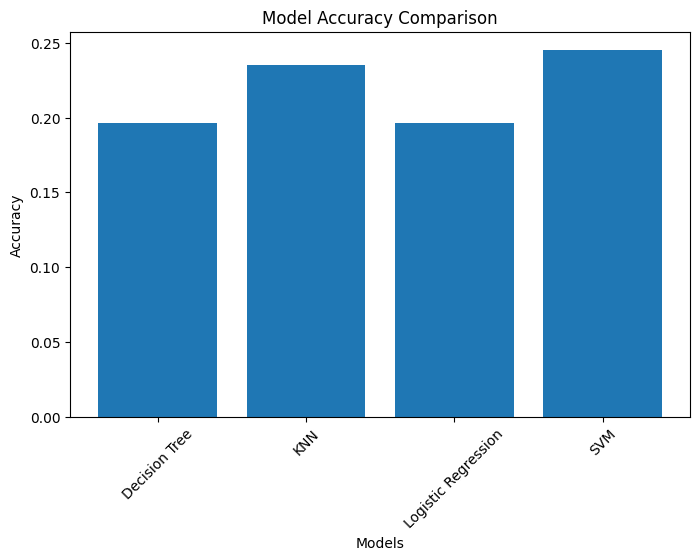

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(model_comparison["Model"], model_comparison["Accuracy"])
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=45)
plt.show()

In [ ]:
import pickle

with open("best_supermarket_model.pkl", "wb") as file:
    pickle.dump(svm_model, file)

In [ ]:
with open("feature_columns.pkl", "wb") as file:
    pickle.dump(x.columns, file)